<a href="https://colab.research.google.com/github/anhndt0310-jpg/vietnamese-cyberbullying-detection/blob/main/vietnamese_cyberbullying_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch pandas numpy scikit-learn xgboost datasets tensorboard
!pip install -U accelerate
!pip install scikit-learn matplotlib

In [2]:
!pip install transformers==4.44.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 32.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transformers-5.9.0


In [3]:
import os
import pandas as pd
if os.path.exists('/workspace'):
    base_path = '/workspace/vietnamese-cyberbullying-detection/'
    os.makedirs(base_path, exist_ok=True)
else:
    base_path = './'

print(f"📁 Dữ liệu sẽ được lưu tại: {base_path}")

📁 Dữ liệu sẽ được lưu tại: ./


In [8]:
import pandas as pd
import os

# --- CẤU HÌNH ĐƯỜNG DẪN ---
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/'
else:
    base_path = './'

# --- NẠP DỮ LIỆU ---
train_df = pd.read_csv(os.path.join(base_path, 'df_train_clean.csv'))
val_df = pd.read_csv(os.path.join(base_path, 'df_dev_clean.csv'))
test_df = pd.read_csv(os.path.join(base_path, 'df_test_clean.csv'))

print("✅ Đã tải dữ liệu thành công!")
print(f"Train: {len(train_df)} dòng | Dev: {len(val_df)} dòng | Test: {len(test_df)} dòng")

✅ Đã tải dữ liệu thành công!
Train: 7000 dòng | Dev: 2000 dòng | Test: 1000 dòng


In [10]:
import os
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer
from tqdm import tqdm

# --- CẤU HÌNH ĐƯỜNG DẪN ---
try:
    from google.colab import drive
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    # Dựa trên danh sách file của bạn, các file nằm trực tiếp trong MyDrive
    base_path = '/content/drive/MyDrive/'
else:
    base_path = './'

# --- ĐỊNH NGHĨA HÀM TRÍCH XUẤT (Để tránh lỗi NameError) ---
def get_phobert_embeddings(texts, batch_size=16):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
    phobert = AutoModel.from_pretrained("vinai/phobert-base").to(device)
    phobert.eval()

    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting features"):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        with torch.no_grad():
            outputs = phobert(**inputs)
        # Lấy vector [CLS] (vị trí index 0)
        batch_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_emb)
    return np.vstack(embeddings)

# --- QUY TRÌNH NẠP HOẶC TRÍCH XUẤT ---
emb_train_path = os.path.join(base_path, 'X_train_emb.npy')
emb_test_path = os.path.join(base_path, 'X_test_emb.npy')

if os.path.exists(emb_train_path) and os.path.exists(emb_test_path):
    print("🔄 Đang nạp đặc trưng từ file có sẵn tại:", base_path)
    X_train_emb = np.load(emb_train_path)
    X_test_emb = np.load(emb_test_path)
    print("✅ Đã nạp xong!")
else:
    print("⚠️ Không tìm thấy file .npy. Đang bắt đầu trích xuất...")
    X_train_emb = get_phobert_embeddings(train_df['content_clean'].fillna('').tolist())
    X_test_emb = get_phobert_embeddings(test_df['content_clean'].fillna('').tolist())

    # Lưu lại để dùng cho lần sau
    np.save(emb_train_path, X_train_emb)
    np.save(emb_test_path, X_test_emb)
    print(f"✅ Đã trích xuất và lưu vào {base_path}!")

y_train = train_df['Toxicity'].values
y_test = test_df['Toxicity'].values

print(f"Kích thước tập Train: {X_train_emb.shape}")
print(f"Kích thước tập Test: {X_test_emb.shape}")

🔄 Đang nạp đặc trưng từ file có sẵn tại: /content/drive/MyDrive/
✅ Đã nạp xong!
Kích thước tập Train: (7000, 768)
Kích thước tập Test: (1000, 768)


In [11]:
# Xác định base_path dựa trên môi trường (đã làm ở bước trước)
# Nếu bạn đã có biến base_path, hãy dùng luôn nó nhé.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import os
save_path = os.path.join(base_path, 'phobert_logreg_model.pkl')

print(f"Đang huấn luyện Logistic Regression...")
lr_final = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_final.fit(X_train_emb, y_train)

# Lưu mô hình vào đường dẫn linh hoạt
joblib.dump(lr_final, save_path)
print(f"✅ Đã lưu mô hình tại: {save_path}")

# Dự đoán và đánh giá
y_pred_lr = lr_final.predict(X_test_emb)

print("\n=== KẾT QUẢ LOGISTIC REGRESSION ===")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Đang huấn luyện Logistic Regression...
✅ Đã lưu mô hình tại: /content/drive/MyDrive/phobert_logreg_model.pkl

=== KẾT QUẢ LOGISTIC REGRESSION ===
[[719 171]
 [ 43  67]]
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       890
           1       0.28      0.61      0.39       110

    accuracy                           0.79      1000
   macro avg       0.61      0.71      0.63      1000
weighted avg       0.87      0.79      0.82      1000



In [12]:
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- CẤU HÌNH PATH (Dựa trên biến base_path đã định nghĩa từ trước) ---
rf_model_path = os.path.join(base_path, 'rf_model.pkl')
xgb_model_path = os.path.join(base_path, 'xgb_model.pkl')

# --- 1. HUẤN LUYỆN HOẶC NẠP RANDOM FOREST ---
if os.path.exists(rf_model_path):
    print("🔄 Đang nạp mô hình Random Forest từ file...")
    rf_model = joblib.load(rf_model_path)
else:
    print("🚀 Đang huấn luyện Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
    rf_model.fit(X_train_emb, y_train)
    joblib.dump(rf_model, rf_model_path)
    print("✅ Đã lưu Random Forest!")

# --- 2. HUẤN LUYỆN HOẶC NẠP XGBOOST ---
if os.path.exists(xgb_model_path):
    print("🔄 Đang nạp mô hình XGBoost từ file...")
    xgb_model = joblib.load(xgb_model_path)
else:
    print("🚀 Đang huấn luyện XGBoost...")
    # Tự động tính tỉ lệ scale_pos_weight nếu là bài toán nhị phân
    scale_weight = (y_train == 0).sum() / (y_train == 1).sum() if 1 in y_train else 1

    xgb_model = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        scale_pos_weight=scale_weight, eval_metric='logloss', random_state=42
    )
    xgb_model.fit(X_train_emb, y_train)
    joblib.dump(xgb_model, xgb_model_path)
    print("✅ Đã lưu XGBoost!")

# --- DỰ ĐOÁN ---
y_pred_rf = rf_model.predict(X_test_emb)
y_pred_xgb = xgb_model.predict(X_test_emb)

print("\n=== KẾT QUẢ SO SÁNH ===")
print("Random Forest Accuracy:", rf_model.score(X_test_emb, y_test))
print("XGBoost Accuracy:", xgb_model.score(X_test_emb, y_test))

🚀 Đang huấn luyện Random Forest...
✅ Đã lưu Random Forest!
🚀 Đang huấn luyện XGBoost...
✅ Đã lưu XGBoost!

=== KẾT QUẢ SO SÁNH ===
Random Forest Accuracy: 0.89
XGBoost Accuracy: 0.893


In [17]:
import os
import torch
from datasets import Dataset, load_from_disk
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score

# --- CẤU HÌNH ---
base_path = '/content/drive/MyDrive/'
data_dir = os.path.join(base_path, 'data_transformers')
results_dir = os.path.join(base_path, 'results_transformers')
model_save_path = os.path.join(base_path, 'phobert_finetuned_toxicity') # Đường dẫn lưu model

os.makedirs(data_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

# 1. LOAD DỮ LIỆU
train_dataset, test_dataset = get_data()

# 2. LOAD MÔ HÌNH (THÔNG MINH HƠN)
def load_model():
    if os.path.exists(model_save_path):
        print(f"✅ Tìm thấy mô hình đã huấn luyện tại: {model_save_path}")
        print("🔍 Đang nạp mô hình cũ để dự đoán...")
        return AutoModelForSequenceClassification.from_pretrained(model_save_path), False # False = Không cần train
    else:
        print("🆕 Không tìm thấy mô hình cũ. Chuẩn bị nạp vinai/phobert-base để huấn luyện mới...")
        return AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=2), True # True = Cần train

model, should_train = load_model()

# 3. THIẾT LẬP TRAINER
training_args = TrainingArguments(
    output_dir=results_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda p: {
        'accuracy': accuracy_score(p.label_ids, p.predictions.argmax(-1)),
        'f1': f1_score(p.label_ids, p.predictions.argmax(-1), average='weighted')
    }
)

# 4. TỰ ĐỘNG CHẠY
if should_train:
    print("🚀 Đang bắt đầu huấn luyện...")
    trainer.train()
    trainer.save_model(model_save_path)
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
    tokenizer.save_pretrained(model_save_path)
    print("✅ Huấn luyện hoàn tất và đã lưu model!")
else:
    print("🔍 Mô hình đã sẵn sàng để dự đoán.")

🚀 Đã tìm thấy dữ liệu đã tokenize! Đang nạp từ Google Drive...
✅ Tìm thấy mô hình đã huấn luyện tại: /content/drive/MyDrive/phobert_finetuned_toxicity
🔍 Đang nạp mô hình cũ để dự đoán...
🔍 Mô hình đã sẵn sàng để dự đoán.


In [19]:
if 'tokenizer' not in globals():
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# 1. Lưu mô hình sau khi Fine-tuning
model_save_path = '/content/drive/MyDrive/phobert_finetuned_toxicity'
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"✅ Đã lưu mô hình fine-tuned tại: {model_save_path}")

# 2. Đánh giá chi tiết trên tập test
evaluations = trainer.evaluate()
print("\n=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===")
for key, value in evaluations.items():
    print(f"{key}: {value}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Đã lưu mô hình fine-tuned tại: /content/drive/MyDrive/phobert_finetuned_toxicity



=== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ===
eval_loss: 0.27991580963134766
eval_model_preparation_time: 0.0029
eval_accuracy: 0.893
eval_f1: 0.8923503854891695
eval_runtime: 2.5683
eval_samples_per_second: 389.36
eval_steps_per_second: 48.67


2. Thêm Các Metric Đánh giá Chi tiết

⏳ Đang thực hiện dự đoán trên tập test...



KẾT QUẢ ĐÁNH GIÁ: PhoBERT Fine-tuned

📊 Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.94      0.94      0.94       890
       Toxic       0.51      0.50      0.51       110

    accuracy                           0.89      1000
   macro avg       0.73      0.72      0.72      1000
weighted avg       0.89      0.89      0.89      1000



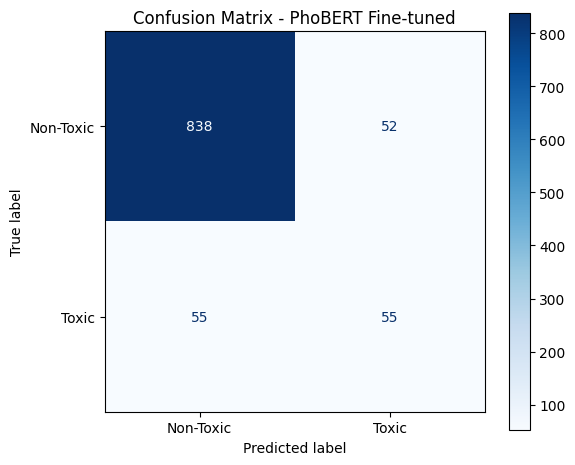


🎯 ROC-AUC Score: 0.8327
🎯 Average Precision: 0.5301


In [22]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    print(f"\n{'='*50}")
    print(f"KẾT QUẢ ĐÁNH GIÁ: {model_name}")
    print('='*50)

    # Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Non-Toxic', 'Toxic']))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['Non-Toxic', 'Toxic'], ax=ax, cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        print(f"\n🎯 ROC-AUC Score: {auc:.4f}")
        print(f"🎯 Average Precision: {ap:.4f}")

try:
    print("⏳ Đang thực hiện dự đoán trên tập test...")
    # Sử dụng trainer để dự đoán
    test_results = trainer.predict(test_dataset)

    # Lấy nhãn dự đoán (0 hoặc 1)
    y_pred = np.argmax(test_results.predictions, axis=1)

    # Lấy xác suất của lớp Toxic (cột 1)
    y_proba = torch.nn.functional.softmax(torch.tensor(test_results.predictions), dim=-1)[:, 1].numpy()

    # Lấy nhãn thực tế
    y_true = test_dataset['label']

    # Gọi hàm đánh giá
    evaluate_model(y_true, y_pred, y_proba, "PhoBERT Fine-tuned")

except Exception as e:
    print(f"❌ Có lỗi xảy ra khi đánh giá: {e}")
    # Gợi ý debug
    import traceback
    traceback.print_exc()

3. Cross-Validation để đánh giá ổn định

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    X_train_emb, y_train,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)

print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Cross-Validation F1 Scores: [0.81914322 0.82581351 0.81671383 0.80354279 0.83139115]
Mean F1: 0.8193 (+/- 0.0188)


4. Lưu và Tải Model

In [28]:
import joblib
import os

# Đảm bảo lưu đúng mô hình Logistic Regression (lr_final)
logreg_path = '/content/drive/MyDrive/phobert_logreg_model.pkl'
joblib.dump(lr_final, logreg_path)

# Lưu embeddings
np.save('/content/drive/MyDrive/X_train_emb.npy', X_train_emb)
np.save('/content/drive/MyDrive/X_test_emb.npy', X_test_emb)

print(f"✅ Đã lưu đúng mô hình Logistic Regression tại: {logreg_path}")

✅ Đã lưu đúng mô hình Logistic Regression tại: /content/drive/MyDrive/phobert_logreg_model.pkl


5. Hàm Dự đoán cho câu mới

In [29]:
import torch
from transformers import AutoModel, AutoTokenizer
import joblib
import os
import numpy as np

# 1. Setup device and embedder
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if 'phobert_base_embedder' not in globals():
    phobert_base_embedder = AutoModel.from_pretrained("vinai/phobert-base").to(device)
if 'tokenizer' not in globals():
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# 2. Re-load the correct Scikit-Learn model
ml_model_path = '/content/drive/MyDrive/phobert_logreg_model.pkl'
sk_classifier = joblib.load(ml_model_path)

def predict_toxicity_ml(text, ml_model, tokenizer, embed_model):
    embed_model.eval()
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = embed_model(**inputs)

    embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    prediction = ml_model.predict(embedding)[0]
    probability = ml_model.predict_proba(embedding)[0]

    result = "🚨 ĐỘC HẠI" if prediction == 1 else "✅ KHÔNG ĐỘC HẠI"
    print(f"Văn bản: {text}")
    print(f"Kết quả: {result} ({probability[1]:.2%} toxic)")
    print("-" * 30)

print("--- TESTING PREDICTION (PhoBERT + Logistic Regression) ---")
predict_toxicity_ml("Bạn thật tuyệt vời!", sk_classifier, tokenizer, phobert_base_embedder)
predict_toxicity_ml("Đồ ngu ngốc vô dụng!", sk_classifier, tokenizer, phobert_base_embedder)

--- TESTING PREDICTION (PhoBERT + Logistic Regression) ---
Văn bản: Bạn thật tuyệt vời!
Kết quả: ✅ KHÔNG ĐỘC HẠI (3.77% toxic)
------------------------------
Văn bản: Đồ ngu ngốc vô dụng!
Kết quả: 🚨 ĐỘC HẠI (98.34% toxic)
------------------------------


6. So sánh nhiều Model (Tổng hợp)

In [37]:
!pip install imbalanced-learn

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import pandas as pd
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_emb, y_train)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
}

results = []
for name, clf in models.items():
    print(f"\n🔄 Đang huấn luyện {name} trên dữ liệu đã SMOTE...")

    clf.fit(X_train_resampled, y_train_resampled)
    y_pred = clf.predict(X_test_emb)

    from sklearn.metrics import f1_score, accuracy_score
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (Weighted)': f1_score(y_test, y_pred, average='weighted'),
        'F1 (Toxic)': f1_score(y_test, y_pred, pos_label=1)
    })

results_df = pd.DataFrame(results).sort_values('F1 (Weighted)', ascending=False)
print("\n" + "="*60)
print("📊 BẢNG SO SÁNH CÁC MÔ HÌNH")
print("="*60)
print(results_df.to_string(index=False))


🔄 Đang huấn luyện Logistic Regression trên dữ liệu đã SMOTE...

🔄 Đang huấn luyện Random Forest trên dữ liệu đã SMOTE...

🔄 Đang huấn luyện SVM trên dữ liệu đã SMOTE...

🔄 Đang huấn luyện MLP Neural Network trên dữ liệu đã SMOTE...

📊 BẢNG SO SÁNH CÁC MÔ HÌNH
              Model  Accuracy  F1 (Weighted)  F1 (Toxic)
                SVM     0.879       0.869425    0.352941
 MLP Neural Network     0.873       0.865065    0.341969
      Random Forest     0.892       0.851441    0.114754
Logistic Regression     0.800       0.826183    0.386503
